## 1. Setup - Download Data and Dependencies

Download the Math StackExchange dataset and the spaCy English model.

In [ ]:
!wget --content-disposition "https://archive.org/download/stackexchange/math.stackexchange.com.7z"

!ls -lh
!apt-get install -y p7zip-full
!7z l math.stackexchange.com.7z
!mkdir data
!7z x math.stackexchange.com.7z Posts.xml -odata

!ls -lh data/Posts.xml

--2026-02-07 13:35:05--  https://archive.org/download/stackexchange/math.stackexchange.com.7z
Resolving archive.org (archive.org)... 207.241.224.2
Connecting to archive.org (archive.org)|207.241.224.2|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://dn720201.ca.archive.org/0/items/stackexchange/math.stackexchange.com.7z [following]
--2026-02-07 13:35:05--  https://dn720201.ca.archive.org/0/items/stackexchange/math.stackexchange.com.7z
Resolving dn720201.ca.archive.org (dn720201.ca.archive.org)... 64.71.129.148
Connecting to dn720201.ca.archive.org (dn720201.ca.archive.org)|64.71.129.148|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3629699855 (3.4G) [application/x-7z-compressed]
Saving to: ‘math.stackexchange.com.7z’

math.stackexchange. 100%[===================>]   3.38G  20.8MB/s    in 2m 28s  

2026-02-07 13:37:34 (23.4 MB/s) - ‘math.stackexchange.com.7z’ saved [3629699855/3629699855]

total 3.4G
-rw-r--r-- 1 root roo

In [ ]:
# Download the larger English model to use as a base or for comparison
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 3.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
from spacy.tokens import DocBin
import spacy
import json

## 2. Data Pipeline - Load, Process, and Split

Stream StackExchange posts, compute tag frequencies, filter to frequent topics, and create train/dev splits. This uses `lxml.etree.iterparse` for memory-efficient XML streaming.

In [ ]:
import random
import re
import os
import shutil
from collections import Counter
from lxml import etree

import spacy
from spacy.tokens import DocBin

paths_to_clean = [
    'train.spacy',
    'dev.spacy',
    'all_data.spacy',
    'output/model-best',
    'output/model-last',
    'config.cfg',
    'base_config.cfg'
]

for path in paths_to_clean:
    if os.path.exists(path):
        if os.path.isdir(path):
            shutil.rmtree(path)
            print(f"Removed directory: {path}")
        else:
            os.remove(path)
            print(f"Removed file: {path}")

os.makedirs('output', exist_ok=True)

def stream_posts(xml_path):
    """Streams StackExchange Posts.xml efficiently."""
    context = etree.iterparse(xml_path, events=("end",), tag="row")
    for _, elem in context:
        yield elem.attrib
        elem.clear()

TAG_RE = re.compile(r"<[^>]+>")

def clean_html(text, max_chars=800):
    if not text:
        return ""
    text = TAG_RE.sub(" ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()[:max_chars]

def extract_tags(tag_string):
    if not tag_string:
        return []
    return tag_string.strip("<>").split("><")

# ============================================
# CONFIGURATION - ADJUST THESE!
# ============================================
SAMPLE_SIZE = 10000
MIN_FREQ = 50
MAX_TAGS_PER_DOC = 2
TRAIN_SPLIT = 0.8
# ============================================

print(f"Processing first {SAMPLE_SIZE:,} posts...")

# Step 1: Compute tag frequencies from sample
print("Step 1/3: Computing tag frequencies...")
tag_counter = Counter()
xml_path = "data/Posts.xml"

for i, post in enumerate(stream_posts(xml_path)):
    if i >= SAMPLE_SIZE:
        break
    tags = extract_tags(post.get("Tags", ""))
    tag_counter.update(tags)

    if (i + 1) % 1000 == 0:
        print(f"  Scanned {i + 1:,} posts...")

# Keep only frequent tags
ALLOWED_TAGS = sorted([
    tag for tag, freq in tag_counter.items()
    if freq >= MIN_FREQ
])

print(f"\nFound {len(ALLOWED_TAGS)} topics with at least {MIN_FREQ} occurrences")
print(f"Top 10 topics: {ALLOWED_TAGS[:10]}")

# Save labels for reference
import json
with open('labels.json', 'w') as f:
    json.dump(ALLOWED_TAGS, f, indent=2)
print("Saved labels to labels.json")

# Step 2: Create training data
print(f"\nStep 2/3: Creating train/dev data from {SAMPLE_SIZE:,} posts...")
nlp = spacy.blank("en")

train_db = DocBin(store_user_data=False)
dev_db = DocBin(store_user_data=False)

docs_created = 0
docs_skipped = 0

for i, post in enumerate(stream_posts(xml_path)):
    if i >= SAMPLE_SIZE:
        break

    text = clean_html(post.get("Body", ""))
    if not text:
        docs_skipped += 1
        continue

    tags = extract_tags(post.get("Tags", ""))
    tags = [t for t in tags if t in ALLOWED_TAGS][:MAX_TAGS_PER_DOC]
    if not tags:
        docs_skipped += 1
        continue

    doc = nlp.make_doc(text)

    # Initialize all labels to 0.0 (CRUCIAL for multilabel)
    doc.cats = {label: 0.0 for label in ALLOWED_TAGS}
    for tag in tags:
        doc.cats[tag] = 1.0

    if random.random() < TRAIN_SPLIT:
        train_db.add(doc)
    else:
        dev_db.add(doc)

    docs_created += 1

    if (i + 1) % 1000 == 0:
        print(f"  Processed {i + 1:,} posts ({docs_created} kept, {docs_skipped} skipped)...")

# Step 3: Save files
print("\nStep 3/3: Saving .spacy files...")
train_db.to_disk("train.spacy")
dev_db.to_disk("dev.spacy")

# Verify
train_count = len(list(DocBin().from_disk('train.spacy').get_docs(nlp.vocab)))
dev_count = len(list(DocBin().from_disk('dev.spacy').get_docs(nlp.vocab)))

print("\n" + "="*60)

print("="*60)
print(f"Sample size:       {SAMPLE_SIZE:,} posts")
print(f"Documents created: {docs_created:,}")
print(f"Documents skipped: {docs_skipped:,}")
print(f"Train set:         {train_count:,} examples")
print(f"Dev set:           {dev_count:,} examples")
print(f"Total topics:      {len(ALLOWED_TAGS)}")
print(f"Min frequency:     {MIN_FREQ}")
print("="*60)

Processing first 10,000 posts...
Step 1/3: Computing tag frequencies...
  Scanned 1,000 posts...
  Scanned 2,000 posts...
  Scanned 3,000 posts...
  Scanned 4,000 posts...
  Scanned 5,000 posts...
  Scanned 6,000 posts...
  Scanned 7,000 posts...
  Scanned 8,000 posts...
  Scanned 9,000 posts...
  Scanned 10,000 posts...

Found 5 topics with at least 50 occurrences
Top 10 topics: ['|calculus|', '|combinatorics|', '|geometry|', '|number-theory|', '|probability|']
Saved labels to labels.json

Step 2/3: Creating train/dev data from 10,000 posts...

Step 3/3: Saving .spacy files...

Sample size:       10,000 posts
Documents created: 285
Documents skipped: 9,715
Train set:         215 examples
Dev set:           70 examples
Total topics:      5
Min frequency:     50


## 2.1 Data Visualization & Data Engineering

Visualize the dataset used to train the multilabel text classifier:
topic frequency distributions, document length statistics, label co-occurrences, and train/dev split breakdown.

In [ ]:


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# --- Reload saved data ---
_nlp = spacy.blank('en')
train_docs = list(DocBin().from_disk('train.spacy').get_docs(_nlp.vocab))
dev_docs   = list(DocBin().from_disk('dev.spacy').get_docs(_nlp.vocab))
all_docs   = train_docs + dev_docs

with open('labels.json') as f:
    all_labels = json.load(f)

# --- Compute statistics ---
topic_counts = Counter()
labels_per_doc = []
doc_lengths = []

for doc in all_docs:
    positive = [l for l, s in doc.cats.items() if s > 0.5]
    topic_counts.update(positive)
    labels_per_doc.append(len(positive))
    doc_lengths.append(len(doc.text))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Dataset Analysis — Math StackExchange TextCat', fontsize=16, fontweight='bold', y=1.01)

# --- 1. Top 20 Topic Frequency ---
ax = axes[0, 0]
top20 = topic_counts.most_common(20)
topics, counts = zip(*top20)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(topics)))
ax.barh(range(len(topics)), counts, color=colors)
ax.set_yticks(range(len(topics)))
ax.set_yticklabels(topics, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Number of Documents')
ax.set_title('Top 20 Most Frequent Topics')
for i, (_, c) in enumerate(top20):
    ax.text(c + max(counts)*0.01, i, str(c), va='center', fontsize=8, fontweight='bold')

# --- 2. Document Length Distribution ---
ax = axes[0, 1]
ax.hist(doc_lengths, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(doc_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(doc_lengths):.0f} chars')
ax.axvline(np.median(doc_lengths), color='orange', linestyle='--', label=f'Median: {np.median(doc_lengths):.0f} chars')
ax.set_xlabel('Document Length (characters)')
ax.set_ylabel('Frequency')
ax.set_title('Document Length Distribution')
ax.legend()

# --- 3. Labels per Document ---
ax = axes[1, 0]
label_dist = Counter(labels_per_doc)
x_vals = sorted(label_dist.keys())
y_vals = [label_dist[x] for x in x_vals]
ax.bar(x_vals, y_vals, color='coral', edgecolor='white')
ax.set_xlabel('Number of Labels per Document')
ax.set_ylabel('Frequency')
ax.set_title('Labels per Document Distribution')
ax.set_xticks(x_vals)
for x, y in zip(x_vals, y_vals):
    ax.text(x, y + max(y_vals)*0.01, str(y), ha='center', fontsize=9, fontweight='bold')

# --- 4. Train / Dev Split + Dataset Stats ---
ax = axes[1, 1]
ax.axis('off')
stats = [
    ['Metric', 'Value'],
    ['Total Documents',   f'{len(all_docs):,}'],
    ['Training Docs',     f'{len(train_docs):,}'],
    ['Dev Docs',          f'{len(dev_docs):,}'],
    ['Total Topics',      f'{len(all_labels)}'],
    ['Avg Labels / Doc',  f'{np.mean(labels_per_doc):.2f}'],
    ['Avg Doc Length',    f'{np.mean(doc_lengths):.0f} chars'],
    ['Median Doc Length', f'{np.median(doc_lengths):.0f} chars'],
    ['Max Doc Length',    f'{max(doc_lengths):,} chars'],
    ['Min Doc Length',    f'{min(doc_lengths):,} chars'],
]
table = ax.table(cellText=stats, cellLoc='left', loc='center',
                 colWidths=[0.55, 0.45])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.2)
for col in range(2):
    table[(0, col)].set_facecolor('#3498DB')
    table[(0, col)].set_text_props(weight='bold', color='white')
ax.set_title('Dataset Statistics', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('dataset_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved dataset_analysis.png')

## 3. Configuration

Generate a spaCy config for `textcat_multilabel` pipeline optimized for efficiency.

In [ ]:
!python -m spacy init config config.cfg --lang en --pipeline textcat_multilabel --optimize efficiency

⚠ To generate a more effective transformer-based config (GPU-only),
install the spacy-transformers package and re-run this command. The config
generated now does not use transformers.
ℹ Generated config template specific for your use case
- Language: en
- Pipeline: textcat_multilabel
- Optimize for: efficiency
- Hardware: CPU
- Transformer: None
✔ Auto-filled config with all values
✔ Saved config
config.cfg
You can now add your data and train your pipeline:
python -m spacy train config.cfg --paths.train ./train.spacy --paths.dev ./dev.spacy


## 3.1 Model Architecture

The `textcat_multilabel` pipeline uses **spaCy's TextCatEnsemble.v2** architecture,
which combines a deep-learning branch (Tok2Vec) with a linear bag-of-words branch
for robust multi-label classification.

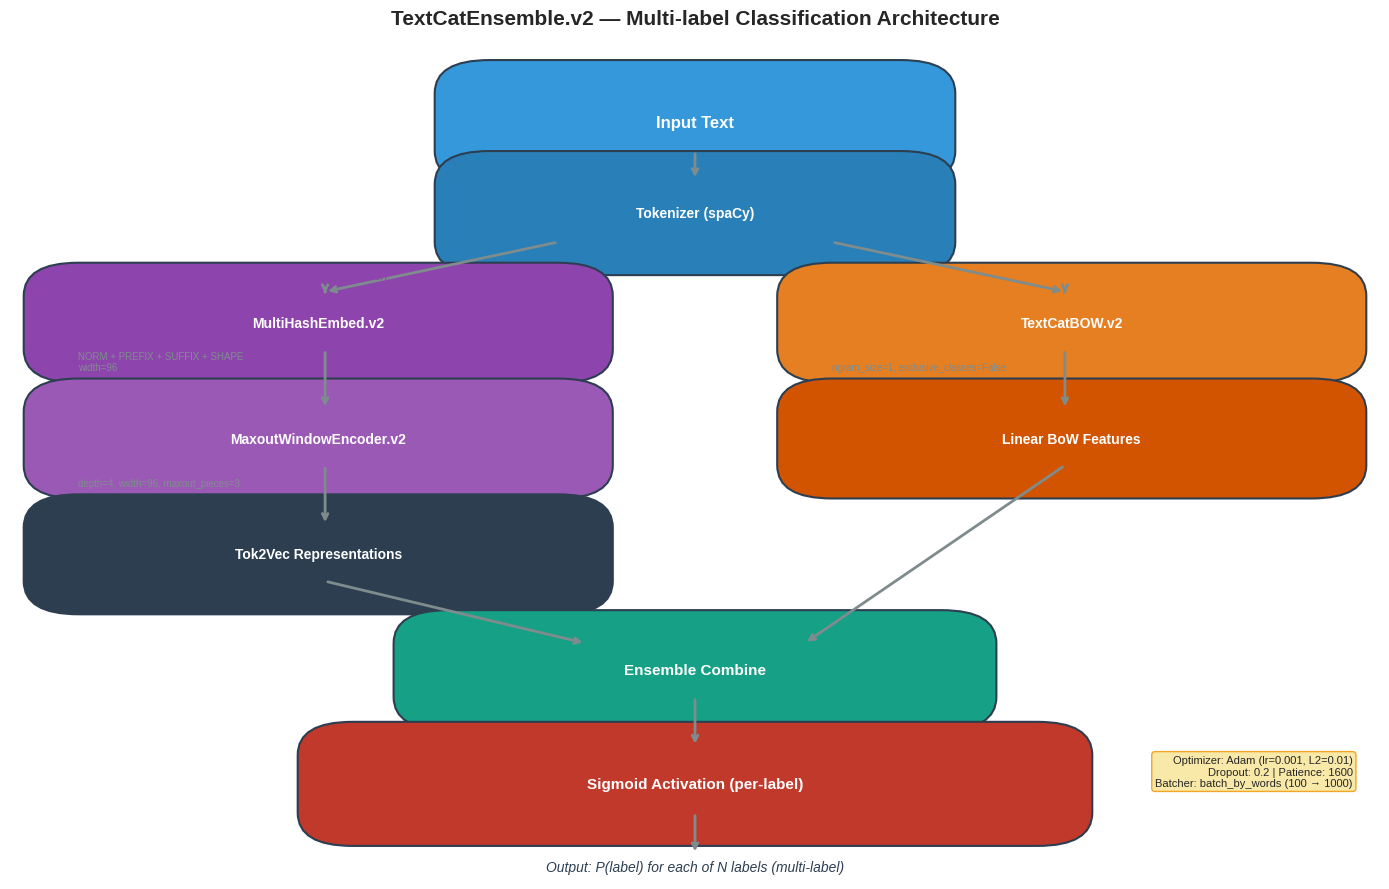

Saved model_architecture.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('TextCatEnsemble.v2 — Multi-label Classification Architecture',
             fontsize=15, fontweight='bold', pad=20)

box_kw = dict(boxstyle='round,pad=0.4', linewidth=1.5)

def draw_box(ax, x, y, w, h, text, color, fontsize=10):
    rect = mpatches.FancyBboxPatch((x, y), w, h, **box_kw,
                                    facecolor=color, edgecolor='#2c3e50')
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color='white' if color not in ['#ecf0f1','#f9e79f'] else '#2c3e50')

def arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=2))

# Input
draw_box(ax, 3.5, 8.8, 3, 0.7, 'Input Text', '#3498db', 12)

# Tokenizer
draw_box(ax, 3.5, 7.7, 3, 0.7, 'Tokenizer (spaCy)', '#2980b9')
arrow(ax, 5, 8.8, 5, 8.45)

# Split into two branches
arrow(ax, 4, 7.7, 2.3, 7.1)
arrow(ax, 6, 7.7, 7.7, 7.1)

# === LEFT BRANCH: Tok2Vec ===
draw_box(ax, 0.5, 6.4, 3.5, 0.65, 'MultiHashEmbed.v2', '#8e44ad')
ax.text(0.5, 6.15, 'NORM + PREFIX + SUFFIX + SHAPE\nwidth=96', fontsize=7, color='#7f8c8d')
arrow(ax, 2.3, 7.1, 2.3, 7.08)

draw_box(ax, 0.5, 5.0, 3.5, 0.65, 'MaxoutWindowEncoder.v2', '#9b59b6')
ax.text(0.5, 4.75, 'depth=4, width=96, maxout_pieces=3', fontsize=7, color='#7f8c8d')
arrow(ax, 2.3, 6.4, 2.3, 5.68)

draw_box(ax, 0.5, 3.6, 3.5, 0.65, 'Tok2Vec Representations', '#2c3e50')
arrow(ax, 2.3, 5.0, 2.3, 4.28)

# === RIGHT BRANCH: Linear BOW ===
draw_box(ax, 6.0, 6.4, 3.5, 0.65, 'TextCatBOW.v2', '#e67e22')
ax.text(6.0, 6.15, 'ngram_size=1, exclusive_classes=False', fontsize=7, color='#7f8c8d')
arrow(ax, 7.7, 7.1, 7.7, 7.08)

draw_box(ax, 6.0, 5.0, 3.5, 0.65, 'Linear BoW Features', '#d35400')
arrow(ax, 7.7, 6.4, 7.7, 5.68)

# === Ensemble merge ===
arrow(ax, 2.3, 3.6, 4.2, 2.85)
arrow(ax, 7.7, 5.0, 5.8, 2.85)
draw_box(ax, 3.2, 2.2, 3.6, 0.65, 'Ensemble Combine', '#16a085', 11)

# === Output ===
arrow(ax, 5, 2.2, 5, 1.6)
draw_box(ax, 2.5, 0.8, 5, 0.7, 'Sigmoid Activation (per-label)', '#c0392b', 11)

arrow(ax, 5, 0.8, 5, 0.3)
ax.text(5, 0.1, 'Output: P(label) for each of N labels (multi-label)',
        ha='center', fontsize=10, fontstyle='italic', color='#2c3e50')

# Branch labels
ax.text(2.3, 7.25, 'Deep Learning Branch', ha='center', fontsize=9, fontstyle='italic', color='#8e44ad')
ax.text(7.7, 7.25, 'Linear Branch', ha='center', fontsize=9, fontstyle='italic', color='#e67e22')

# Optimizer info box
opt_text = ('Optimizer: Adam (lr=0.001, L2=0.01)\n'
            'Dropout: 0.2 | Patience: 1600\n'
            'Batcher: batch_by_words (100 → 1000)')
ax.text(9.8, 1.5, opt_text, fontsize=8, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='#f9e79f', edgecolor='#f39c12', alpha=0.9))

plt.tight_layout()
plt.savefig('model_architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved model_architecture.png')

## 4. Training

Text categorization typically converges faster than NER.

In [ ]:
!python -m spacy train config.cfg \
    --output ./output \
    --paths.train ./train.spacy \
    --paths.dev ./dev.spacy \
    --gpu-id 0

ℹ Saving to output directory: output
ℹ Using GPU: 0

=========================== Initializing pipeline ===========================
✔ Initialized pipeline

============================= Training pipeline =============================
ℹ Pipeline: ['textcat_multilabel']
ℹ Initial learn rate: 0.001
E    #       LOSS TEXTC...  CATS_SCORE  SCORE 
---  ------  -------------  ----------  ------
  0       0           0.25       51.48    0.51
  1     200          30.30       76.25    0.76
  2     400          11.14       84.06    0.84
  3     600           3.95       85.67    0.86
  4     800           1.75       86.26    0.86
  6    1000           0.80       86.30    0.86
  8    1200           0.49       86.10    0.86
 11    1400           0.34       86.19    0.86
 14    1600           0.22       85.96    0.86
 18    1800           0.15       85.93    0.86
 23    2000           0.10       85.91    0.86
 30    2200           0.07       85.82    0.86
 38    2400           0.05       85.88    0.86

## 5. Evaluation

**Key Change**: We examine `doc.cats` instead of `doc.ents`.

In [ ]:
nlp_best = spacy.load("output/model-best")

# Test on various mathematical questions
test_texts = [
    "Explain why a^2 + b^2 = c^2 holds for right triangles",
    "What is the relationship between the sides of a right triangle?",
    "How do you compute the determinant of a 3x3 matrix?",
    "What is the derivative of sin(x)?",
    "Explain Bayes' theorem with an example",
    "What are prime numbers and how do you test for primality?"
]

print("\n" + "="*80)
print("TOPIC EXTRACTION RESULTS")
print("="*80 + "\n")

for text in test_texts:
    doc = nlp_best(text)

    print(f"Text: {text}")
    print(f"\nDetected topics:")

    # Sort by confidence score
    sorted_cats = sorted(doc.cats.items(), key=lambda x: x[1], reverse=True)

    # Show top 5 predictions
    for topic, score in sorted_cats[:5]:
        if score > 0.1:  # Only show if reasonably confident
            print(f"  - {topic}: {score:.3f}")

    # Get the most likely topic
    top_topic = max(doc.cats, key=doc.cats.get)
    print(f"\n  → Primary topic: {top_topic} ({doc.cats[top_topic]:.3f})")
    print("\n" + "-"*80 + "\n")


TOPIC EXTRACTION RESULTS

Text: Explain why a^2 + b^2 = c^2 holds for right triangles

Detected topics:
  - |number-theory|: 0.483
  - |calculus|: 0.474
  - |geometry|: 0.401
  - |probability|: 0.386
  - |combinatorics|: 0.362

  → Primary topic: |number-theory| (0.483)

--------------------------------------------------------------------------------

Text: What is the relationship between the sides of a right triangle?

Detected topics:
  - |geometry|: 0.537
  - |probability|: 0.491
  - |calculus|: 0.389
  - |combinatorics|: 0.296
  - |number-theory|: 0.240

  → Primary topic: |geometry| (0.537)

--------------------------------------------------------------------------------

Text: How do you compute the determinant of a 3x3 matrix?

Detected topics:
  - |geometry|: 0.477
  - |probability|: 0.420
  - |combinatorics|: 0.376
  - |calculus|: 0.352
  - |number-theory|: 0.270

  → Primary topic: |geometry| (0.477)

-------------------------------------------------------------------------